# How to desaturate stars ?

In this example we download GAIA stars in a sky direction and use the time of the observation to compute their position in the image.

In [1]:
# Get the list of coordinates at the time of the observation
from flo.simutils import gaiastars
import roman_datamodels as rdm


ra, dec = 161.24417091, 57.96563985  # Center of a skycell
radius = 0.12  # Radius of the catalog in degrees

with rdm.open('/Users/dfadda/Roman/EPSF/GalaxyField_wfi01_f146_cal.asdf') as dm:
    start_time = dm.meta.exposure.start_time

# Retrieve catalog and save it locally
gaia_catalog = gaiastars(ra=ra, dec=dec, radius=radius, star=0.7, maglim=16, obs_time=start_time)
gaia_catalog.write('/Users/dfadda/Roman/EPSF/gaia_catalog.ecsv', format='ascii.ecsv', overwrite=True)


Matplotlib is building the font cache; this may take a moment.
2026-08-03 12:23:17 INFO     Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


In [1]:
# Desaturate the PSFs
from flo.desaturate import desaturatePsf
from astropy.coordinates import SkyCoord
from astropy.table import Table

gaia_catalog = Table.read('/Users/dfadda/Roman/EPSF/gaia_catalog.ecsv')
stars = SkyCoord(gaia_catalog['ra'].value, gaia_catalog['dec'].value, unit='deg', frame = 'icrs')

L2 = '/Users/dfadda/Roman/EPSF/GalaxyField_wfi01_f146_cal.asdf'
desaturatePsf(L2, stars)

There are  6  bright stars which will be corrected
914107.9
23456.291
24171.285
150451.4
35786.32
570528.4


Number of corrected stars  6
Star number:  5
Position of star:  4043 1244


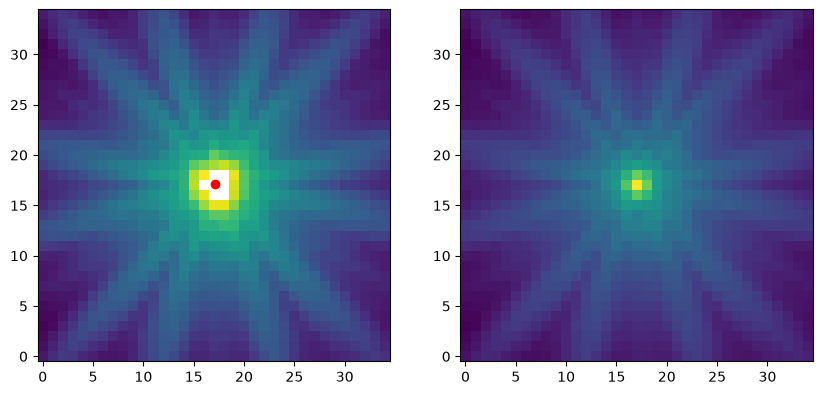

In [5]:
# Comparison between before and after
import roman_datamodels as rdm
import numpy as np
import matplotlib.pyplot as plt

path = '/Users/dfadda/Roman/EPSF/'
with rdm.open(path+'GalaxyField_wfi01_f146_cal.asdf') as dm:
    image = dm.data.copy()
    wcs = dm.meta.wcs
with rdm.open(path+'GalaxyField_wfi01_f146_cal_us.asdf') as dm:
    imageus = dm.data.copy()

ra, dec = stars.ra.deg, stars.dec.deg
x, y = wcs.backward_transform(ra, dec)
idx = (x >= 17) & (x < 4088-17) & (y >= 17) & (y < 4088-17)  
x, y = x[idx], y[idx]
ra, dec = ra[idx], dec[idx]
sstars = stars[idx]
print('Number of corrected stars ', len(sstars))
xx = np.round(x).astype(int)
yy = np.round(y).astype(int)
dx = np.floor((x - xx)*10).astype(int)
dy = np.floor((y - yy)*10).astype(int)

# Source number
i=5
print('Star number: ', i)
print('Position of star: ', xx[i], yy[i])
subimage = image[yy[i]-17:yy[i]+18, xx[i]-17:xx[i]+18]
subimageus = imageus[yy[i]-17:yy[i]+18, xx[i]-17:xx[i]+18]

fig,(ax1,ax2) =  plt.subplots(1,2,figsize=(10,5))
ax1.imshow(np.log10(subimage), origin='lower')
ax1.scatter(x=17+dx[i]*0.1, y=17+dy[i]*0.1, color='red')
ax2.imshow(np.log10(subimageus), origin='lower')
plt.show()